# PF 추정 잔차를 학습하는 모델
- 잔차를 ML이 보정
- 최종 예측 = pred_pf + ML이 예측한 잔차

In [3]:
## 1. import + 기존 함수 가져오기

In [6]:
import os, glob, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import GroupKFold

warnings.filterwarnings('ignore')

# 07_physical_pf.ipynb 함수 가져오기
def find_input_dir():
    for c in ['/kaggle/input/competitions/rogii-wellbore-geology-prediction',
              '../data/raw']:
        if os.path.isdir(c):
            return c
    raise FileNotFoundError('데이터 경로를 찾을 수 없음')

INPUT_DIR = find_input_dir()
TRAIN_DIR = os.path.join(INPUT_DIR, 'train')
TEST_DIR  = os.path.join(INPUT_DIR, 'test')
print(f'INPUT_DIR = {INPUT_DIR}')

# 우물 ID 목록
_train_files = sorted(glob.glob(os.path.join(TRAIN_DIR, '*__horizontal_well.csv')))
_test_files  = sorted(glob.glob(os.path.join(TEST_DIR,  '*__horizontal_well.csv')))
TRAIN_WIDS = [os.path.basename(f).split('__')[0] for f in _train_files]
TEST_WIDS  = [os.path.basename(f).split('__')[0] for f in _test_files]
print(f'Train wells: {len(TRAIN_WIDS)}, Test wells: {len(TEST_WIDS)}')

def load_well(wid, split='train'):
    base = TRAIN_DIR if split == 'train' else TEST_DIR
    hw = pd.read_csv(os.path.join(base, f'{wid}__horizontal_well.csv'))
    tw = pd.read_csv(os.path.join(base, f'{wid}__typewell.csv'))
    return hw, tw

def run_particle_filter(hw, tw, n_particles=2000, seed=42):
    """
    GR 매칭 기반 Particle Filter (baseline 파라미터).
    """
    tw_s = tw.sort_values('TVT')
    tw_tvt = tw_s['TVT'].values.astype(float)
    tw_gr  = tw_s['GR'].fillna(tw_s['GR'].mean()).values.astype(float)

    kn = hw[hw['TVT_input'].notna()]
    ev = hw[hw['TVT_input'].isna()]
    if len(ev) == 0:
        return hw['TVT_input'].values.astype(float).copy(), 0.0

    last_tvt = float(kn.iloc[-1]['TVT_input'])
    last_Z   = float(kn.iloc[-1]['Z'])
    last_MD  = float(kn.iloc[-1]['MD'])

    # GR 잡음 계산 (known 구간의 GR 잔차 std)
    tw_at_k = np.interp(kn['TVT_input'].values, tw_tvt, tw_gr)
    gs = float(np.clip(np.nanstd(kn['GR'].fillna(0).values - tw_at_k), 10., 60.))

    # 최근 30개 지점에서 진행률(rate) 계산: 깊이 변화 속도
    tail = kn.tail(30)
    dt = np.diff(tail['TVT_input'].values)
    dz = np.diff(tail['Z'].values)
    dm = np.diff(tail['MD'].values)
    m  = dm > 0
    ir = float(np.median((dt + dz)[m] / dm[m])) if m.sum() >= 3 else 0.0

    # === Motion / observation 파라미터 (baseline) ===
    MOM    = 0.998   # momentum
    VN     = 0.002   # velocity noise
    PN     = 0.005   # position noise
    RP     = 0.1     # resample 후 position perturbation
    RR     = 0.001   # resample 후 rate perturbation
    RESAMP = 0.5     # n_eff < RESAMP*N 일 때 resample

    # 가상의 드릴 N개 초기화
    N = n_particles
    rng = np.random.default_rng(seed)
    ls  = last_tvt + last_Z
    pos  = ls + 2.0 * rng.standard_normal(N)
    rate = ir + 0.01 * rng.standard_normal(N)
    w    = np.ones(N) / N

    md_v = ev['MD'].values.astype(float)
    z_v  = ev['Z'].values.astype(float)
    gr_interp = hw['GR'].interpolate(limit_direction='both').fillna(tw_gr.mean())
    gr_v = gr_interp.values.astype(float)[ev.index]

    out_vals = hw['TVT_input'].values.astype(float).copy()
    res = np.empty(len(ev))
    prev_MD = last_MD
    log_lik = 0.0

    for i in range(len(ev)):
        dm_step = max(md_v[i] - prev_MD, 1.0)
        rate = MOM * rate + VN * rng.standard_normal(N)
        pos  = pos + rate * dm_step + PN * rng.standard_normal(N)
        tvt_p = pos - z_v[i]
        tvt_p = np.clip(tvt_p, tw_tvt[0] - 100, tw_tvt[-1] + 100)
        pos   = tvt_p + z_v[i]

        # Likelihood: GR mismatch에 Gaussian
        eg = np.interp(tvt_p, tw_tvt, tw_gr)
        d  = (gr_v[i] - eg) / gs
        lk = np.maximum(np.exp(-0.5 * np.minimum(d**2, 600.)), 1e-300)

        avg_lk = float((w * lk).sum())
        log_lik += np.log(max(avg_lk, 1e-300))
        w *= lk
        ws = w.sum()
        w = w / ws if ws > 0 else np.ones(N) / N

        # Resampling
        if 1.0 / (w**2).sum() < RESAMP * N:
            cum = np.cumsum(w)
            u0  = rng.uniform(0, 1.0 / N)
            idx = np.clip(np.searchsorted(cum, u0 + np.arange(N) / N), 0, N - 1)
            pos  = pos[idx]  + RP * rng.standard_normal(N)
            rate = rate[idx] + RR * rng.standard_normal(N)
            w    = np.ones(N) / N

        res[i] = float(np.dot(w, pos - z_v[i]))
        prev_MD = md_v[i]

    out_vals[list(ev.index)] = res
    return out_vals, log_lik

def run_pf_lik_ensemble(hw, tw, n_particles=500, n_seeds=16,
                        target_n_eff_ratio=0.3, return_internals=False):
    """
    여러 seed로 PF 돌리고 log-likelihood 가중평균.
    """
    preds, liks = [], []
    for s in range(n_seeds):
        p, ll = run_particle_filter(hw, tw, n_particles=n_particles, seed=s)
        preds.append(p)
        liks.append(ll)

    liks = np.array(liks)
    scale = 5.0
    weights = np.exp((liks - liks.max()) / scale)
    weights /= weights.sum()
    ensemble_pred = (weights[:, None] * np.stack(preds, 0)).sum(0)
    if return_internals:
        return ensemble_pred, liks, weights
    return ensemble_pred

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


INPUT_DIR = ../data/raw
Train wells: 773, Test wells: 3


## 2. TVT 외삽 함수 + feature 추출 함수

In [7]:
def predict_geometric(hw):
    """GR 무시, 마지막 known rate로 TVT 직선 외삽. PF가 GR에 휘둘릴 때의 '기준선'."""
    kn = hw[hw['TVT_input'].notna()]
    ev = hw[hw['TVT_input'].isna()]
    out = hw['TVT_input'].values.astype(float).copy()
    if len(ev) == 0:
        return out
    last_tvt = float(kn.iloc[-1]['TVT_input'])
    last_Z   = float(kn.iloc[-1]['Z'])
    last_MD  = float(kn.iloc[-1]['MD'])
    tail = kn.tail(30)
    dt = np.diff(tail['TVT_input'].values)
    dz = np.diff(tail['Z'].values)
    dm = np.diff(tail['MD'].values)
    m  = dm > 0
    ir = float(np.median((dt + dz)[m] / dm[m])) if m.sum() >= 3 else 0.0
    ls   = last_tvt + last_Z
    md_v = ev['MD'].values.astype(float)
    z_v  = ev['Z'].values.astype(float)
    out[list(ev.index)] = (ls + ir * (md_v - last_MD)) - z_v
    return out

def extract_point_features(hw, pred_pf):
    """예측 구간의 점마다 ML이 볼 '단서표'를 만든다."""
    df = hw
    gr = df['GR'].interpolate(limit_direction='both')        # GR 구멍(NaN) 메우기
    md = df['MD'].values.astype(float)

    feat = pd.DataFrame(index=df.index)

    # --- GR을 여러 크기 돋보기로 본 통계 ---
    for w in [5, 15, 30, 60]:
        r = gr.rolling(w, center=True, min_periods=1)
        feat[f'gr_mean_{w}'] = r.mean()
        feat[f'gr_std_{w}']  = r.std().fillna(0.0)
        feat[f'gr_min_{w}']  = r.min()
        feat[f'gr_max_{w}']  = r.max()
    feat['gr']      = gr.values
    feat['gr_grad'] = np.gradient(gr.values, md)             # GR 변화율 dGR/dMD

    # --- 기하(위치) 정보 ---
    feat['MD'] = md
    feat['Z']  = df['Z'].values
    last_md = float(df.loc[df['TVT_input'].notna(), 'MD'].iloc[-1])
    feat['dist_from_ps'] = md - last_md                      # 예측 시작점부터 거리
    feat['z_grad'] = np.gradient(df['Z'].values, md)         # 우물 기울기 dZ/dMD

    # --- PF가 흘린 단서 ---
    feat['pred_pf']      = pred_pf
    feat['pred_pf_grad'] = np.gradient(pred_pf, md)
    feat['pf_minus_geom'] = pred_pf - predict_geometric(hw)  # PF와 외삽의 불일치도

    return feat

In [8]:
def build_residual_dataset(wids, n_seeds=16, cache_path='../data/processed/resid_ds.pkl'):
    # 이미 만들어 둔 캐시가 있으면 그대로 불러오기 (PF 재계산 생략)
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            return pickle.load(f)

    X_list, y_list, g_list = [], [], []
    for i, wid in enumerate(wids):
        hw, tw = load_well(wid, 'train')
        mask = hw['TVT_input'].isna().values
        if mask.sum() == 0:
            continue

        # 안정적인 PF 예측 (여러 seed 가중평균) + 내부값(liks, weights)
        pred_pf, liks, weights = run_pf_lik_ensemble(
            hw, tw, n_seeds=n_seeds, return_internals=True)

        feat = extract_point_features(hw, pred_pf)

        # 우물 단위 단서를 모든 행에 같은 값으로 붙이기(broadcast)
        n_eval = int(mask.sum())
        feat['log_lik_ps'] = float(liks.max()) / n_eval        # PF의 자신감(스텝당)
        feat['n_eff']      = 1.0 / (weights ** 2).sum()        # 의견이 모였나 갈렸나

        feat = feat[mask]                                      # hidden 점만 학습 대상
        target = hw['TVT'].values[mask] - pred_pf[mask]        # 잔차 = 정답 - PF

        X_list.append(feat)
        y_list.append(target)
        g_list.extend([wid] * len(feat))
        print(f'[{i+1}/{len(wids)}] {wid}  points={len(feat)}')

    X = pd.concat(X_list, ignore_index=True)
    y = np.concatenate(y_list)
    groups = np.array(g_list)

    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    with open(cache_path, 'wb') as f:
        pickle.dump((X, y, groups), f)
    return X, y, groups


N_WELLS_ML = 150          # 처음엔 150개로 빠르게 검증 (나중에 늘리기)
X, y, groups = build_residual_dataset(TRAIN_WIDS[:N_WELLS_ML], n_seeds=16)
print(f'\nX shape={X.shape}, y shape={y.shape}, 우물 수={len(np.unique(groups))}')
print(f'잔차 통계: mean={y.mean():.3f}  std={y.std():.3f}  '
      f'|y|평균={np.abs(y).mean():.3f}')

[1/150] 000d7d20  points=3836
[2/150] 00bbac68  points=6014
[3/150] 00e12e8b  points=4301
[4/150] 015fe0d2  points=4296
[5/150] 01869cd4  points=5557
[6/150] 01982c1d  points=3941
[7/150] 028d7b28  points=6234
[8/150] 02e7fe5a  points=5108
[9/150] 0390d174  points=4411
[10/150] 03a935ae  points=2786
[11/150] 044af7d1  points=4519
[12/150] 0498acab  points=4798
[13/150] 052d64df  points=2445
[14/150] 05948241  points=3879
[15/150] 059c8f24  points=6258
[16/150] 05a0ee4d  points=4348
[17/150] 060ab2b8  points=6258
[18/150] 06df5958  points=3509
[19/150] 071d7b45  points=3211
[20/150] 0849b4e2  points=5537
[21/150] 084d66f9  points=3885
[22/150] 08fecf00  points=5574
[23/150] 09053135  points=5907
[24/150] 09441b8d  points=5488
[25/150] 0955cd6c  points=5195
[26/150] 09ec2ca9  points=5885
[27/150] 0a57a29c  points=5821
[28/150] 0bbf5e67  points=4298
[29/150] 0be01c24  points=4738
[30/150] 0c1b160c  points=5054
[31/150] 0d99f8e4  points=5823
[32/150] 0dc5e64d  points=4879
[33/150] 0dc835f3

In [9]:
gkf = GroupKFold(n_splits=5)
oof = np.zeros(len(y))                  # out-of-fold 예측 담을 그릇
models = []

for fold, (tr, va) in enumerate(gkf.split(X, y, groups)):
    model = lgb.LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=50,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X.iloc[tr], y[tr],
              eval_set=[(X.iloc[va], y[va])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    oof[va] = model.predict(X.iloc[va])
    models.append(model)
    fold_rmse = np.sqrt(np.mean((y[va] - oof[va]) ** 2))
    print(f'fold {fold}: val 잔차 RMSE = {fold_rmse:.4f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026167 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6496
[LightGBM] [Info] Number of data points in the train set: 586444, number of used features: 27
[LightGBM] [Info] Start training from score 1.333032
fold 0: val 잔차 RMSE = 15.4015
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008640 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6476
[LightGBM] [Info] Number of data points in the train set: 586184, number of used features: 27
[LightGBM] [Info] Start training from score 0.880876
fold 1: val 잔차 RMSE = 10.5567
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006165 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

baseline PF RMSE : 11.0654
PF + 잔차보정 RMSE: 10.7864
개선량           : +0.2790

=== baseline 나쁜 우물 Top 10 ===
     wid   base  corrected   gain
1b1eba53 52.027     38.105 13.922
1fdbba44 38.195     33.603  4.592
206b6193 30.482     30.099  0.383
113011eb 28.881     29.065 -0.185
1a68190b 28.690     27.726  0.964
1b1c5372 27.083     28.513 -1.430
200d233d 26.707     26.698  0.009
2d35f86d 24.932     24.703  0.229
173ed841 24.559     21.537  3.022
137d1e44 22.959     21.346  1.613

개선 우물 68 / 악화 82


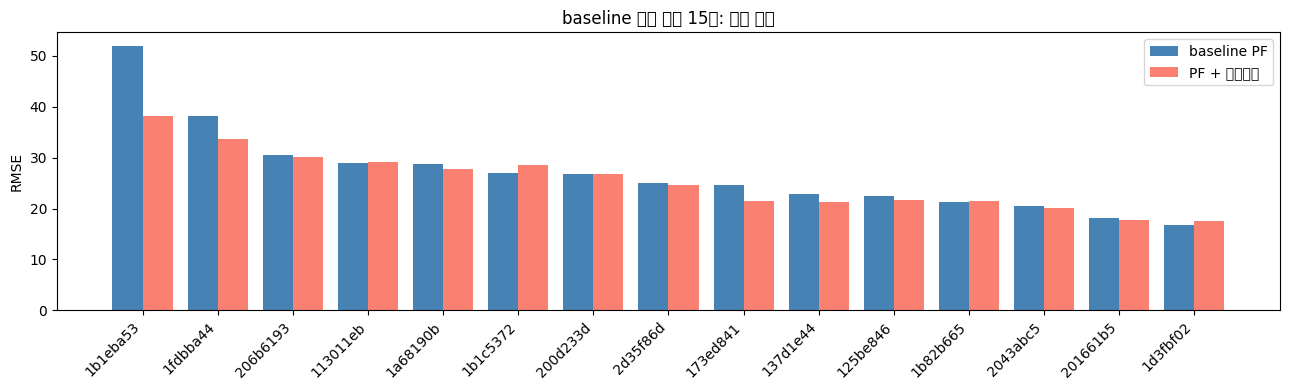

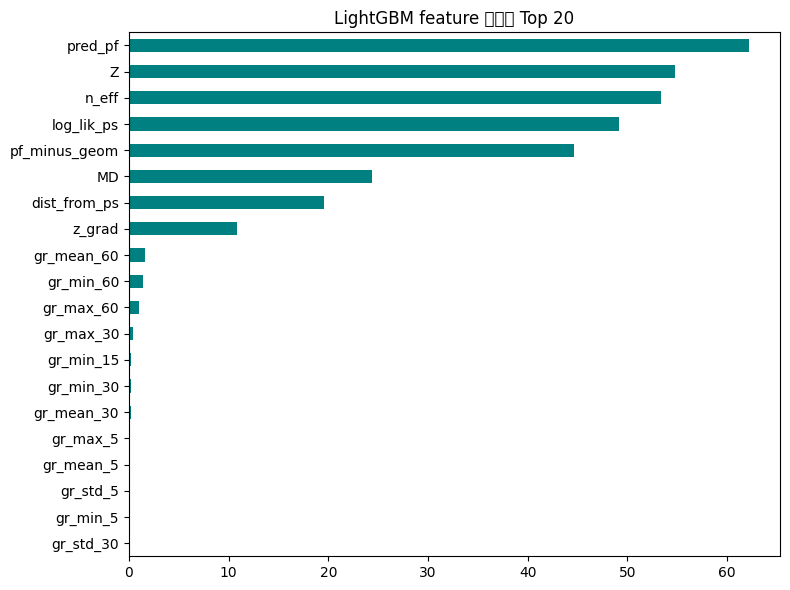

In [10]:
# 전체 RMSE: baseline(PF만) vs 보정(PF + ML)
base_rmse = np.sqrt(np.mean(y ** 2))               # 잔차 그대로 = PF 오차
corr_rmse = np.sqrt(np.mean((y - oof) ** 2))       # 잔차를 ML이 맞힌 뒤 남은 오차
print(f'baseline PF RMSE : {base_rmse:.4f}')
print(f'PF + 잔차보정 RMSE: {corr_rmse:.4f}')
print(f'개선량           : {base_rmse - corr_rmse:+.4f}')

# 우물별 비교 (보정이 어떤 우물을 살리고 어떤 우물을 망치나)
ev_rows = []
for wid in np.unique(groups):
    m = groups == wid
    b = np.sqrt(np.mean(y[m] ** 2))
    c = np.sqrt(np.mean((y[m] - oof[m]) ** 2))
    ev_rows.append({'wid': wid, 'base': b, 'corrected': c, 'gain': b - c})
df_ev = pd.DataFrame(ev_rows).sort_values('base', ascending=False)

print('\n=== baseline 나쁜 우물 Top 10 ===')
print(df_ev.head(10).round(3).to_string(index=False))
print(f"\n개선 우물 {int((df_ev['gain']>0).sum())} / 악화 {int((df_ev['gain']<0).sum())}")

# 막대그래프: 나쁜 우물에서 보정 효과
top = df_ev.head(15)
x = np.arange(len(top))
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - 0.2, top['base'],      0.4, label='baseline PF', color='steelblue')
ax.bar(x + 0.2, top['corrected'], 0.4, label='PF + 잔차보정', color='salmon')
ax.set_xticks(x); ax.set_xticklabels(top['wid'], rotation=45, ha='right')
ax.set_ylabel('RMSE'); ax.set_title('baseline 나쁜 우물 15개: 보정 전후')
ax.legend(); plt.tight_layout(); plt.show()

# feature 중요도 (어떤 단서가 보정에 쓰였나)
imp = np.mean([m.feature_importances_ for m in models], axis=0)
imp_s = pd.Series(imp, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
imp_s.head(20).iloc[::-1].plot(kind='barh', ax=ax, color='teal')
ax.set_title('LightGBM feature 중요도 Top 20')
plt.tight_layout(); plt.show()